# Reinforcement Learning for Feature Selection

## Introduction

In this notebook, we implement a **Q-learning-based feature selection** system. The goal is to treat feature selection as a reinforcement learning (RL) problem where an agent learns to sequentially select features that maximize classification performance while minimizing the number of features used.

### Problem Formulation

Following the project requirements and the theoretical background from the provided papers ("Dynamic feature selection algorithm based on Q-learning mechanism" and "FEATURE SELECTION USING REINFORCEMENT LEARNING"):

- **State**: A binary vector representing the features selected so far. For our dataset with multiple features, the state is an n-dimensional vector where 1 means the feature is selected and 0 means it is not.

- **Actions**: The action space is the set of all remaining features that haven't been selected yet. The agent can either select a feature or decide to stop selecting features.

- **Rewards**:
  - Positive reward when feature selection improves classification accuracy
  - Negative reward if the selected feature doesn't improve performance or leads to overfitting
  - Penalty for selecting too many features (to encourage simplicity and avoid overfitting)

- **Goal**: Learn to select an optimal subset of features that maximizes classifier accuracy while minimizing the number of features used.

### Model Selection

Based on analysis of the previous notebooks (see combined.ipynb), the **two best performing models** are:

1. **SVM (Linear Kernel, C=5)**: Achieved 100% test accuracy with 99.96% CV accuracy. The linear kernel with proper regularization showed excellent generalization.

2. **Random Forest**: Achieved strong test accuracy with good generalization. Ensemble method that is robust and handles feature interactions well.

These models will be used as the base classifiers for evaluating feature subsets during Q-learning.

## 1. Imports and Setup

In [1]:
# =========================================================
#                   IMPORTS
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Sklearn imports
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Set random seed for reproducibility
np.random.seed(42)

print("All imports successful!")

All imports successful!


## 2. Load and Prepare Data

In [2]:
# =========================================================
#                   LOAD DATA
# =========================================================

# Load the dataset
# Note: The dataset uses European decimal format (comma as decimal separator)
# We handle this by specifying decimal=',' in read_csv
data = pd.read_csv('../../datasets/group_14.csv', decimal=',')

print("===== DATASET SHAPE =====")
print(f"Rows: {data.shape[0]}, Columns: {data.shape[1]}")
print("\n===== FIRST ROWS =====")
data.head()

===== DATASET SHAPE =====
Rows: 3000, Columns: 49

===== FIRST ROWS =====


,duration_1,duration_2,duration_3,duration_4,duration_5,loudness_level,popularity_level,tempo_class,time_signature,key_mode,...,is_instrumental,is_dance_hit,temp_zscore,resonance_factor,timbre_index,echo_constant,distorted_movement,signal_power,target_class,target_regression
0,0.0,0.0,1.0,0.0,0.0,4.0,4.0,1.0,0.2218242027933286,0.7673876275060306,...,0.0,0.0,-0.5647318414559509,0.6125606837741009,0.47300843659010705,1,0.951926887559824,0.201,class_45,1.917123485878192
1,0.0,0.0,1.0,0.0,0.0,0.0,4.0,1.0,0.2218242027933286,-0.6677083069731333,...,0.0,0.0,-0.5672336519492115,1.3919716568452027,0.7389981675095413,1,1.1075087640816756,0.864,class_45,2.320622969726563
2,0.0,0.0,0.0,1.0,0.0,3.0,4.0,1.0,0.2218242027933286,1.0487789872078277,...,0.0,0.0,-0.4046159698872797,0.3419711551264461,0.387794914290183,1,-1.975317307740197,0.863,class_45,2.230956417760258
3,0.0,0.0,1.0,0.0,0.0,3.0,3.0,1.0,0.2218242027933286,-0.3581778113011568,...,0.0,0.0,1.596398777568946,-0.02053121580920528,0.546116362632361,1,1.2573283488804958,0.961,class_45,0.3927921024510136
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.2218242027933286,1.0487789872078277,...,0.0,0.0,0.9284820908148824,0.7255214659988233,0.38813316384282726,1,-0.9553916727636148,0.671,class_45,1.6032905539961255


In [3]:
# =========================================================
#              PREPARE FEATURES AND TARGET
# =========================================================

# Identify target column (classification target)
target_col = 'target_class'

# Filter data for commas
data['focus_factor'] = data['focus_factor'].astype(str).str.replace(',', '.').astype(float)

# Separate features and target
# Exclude both target columns (classification and regression)
feature_cols = [col for col in data.columns if col not in ['target_class', 'target_regression']]
X = data[feature_cols]
y = data[target_col]

# Encode target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"Number of features: {len(feature_cols)}")
print(f"\nFeature names:")
for i, col in enumerate(feature_cols):
    print(f"  {i}: {col}")

print(f"\n===== CLASS DISTRIBUTION =====")
print(y.value_counts())

Number of features: 47

Feature names:
  0: duration_1
  1: duration_2
  2: duration_3
  3: duration_4
  4: duration_5
  5: loudness_level
  6: popularity_level
  7: tempo_class
  8: time_signature
  9: key_mode
  10: artist_song_count
  11: album_freq
  12: movement_index
  13: intensity_level
  14: verbal_density
  15: purity_score
  16: positivity_index
  17: activity_rate
  18: loudness_intensity
  19: happy_dance
  20: acoustics_instrumental
  21: artists_avg_popularity
  22: tempo_vs_genre
  23: energy_rank_pct
  24: loud_energy_ratio
  25: mood_pca
  26: mood_cluster
  27: acoustic_valence_mood_cluster
  28: explicit
  29: signal_strength
  30: mode_indicator
  31: focus_factor
  32: ambient_level
  33: key_sin
  34: key_cos
  35: duration_log
  36: duration_log_z
  37: time_signature_class_boolean
  38: loudness_yeo
  39: is_instrumental
  40: is_dance_hit
  41: temp_zscore
  42: resonance_factor
  43: timbre_index
  44: echo_constant
  45: distorted_movement
  46: signal_power

In [4]:
# =========================================================
#       TRAIN-TEST SPLIT + STANDARDIZATION
# =========================================================

# Split data: 70% train, 30% test (stratified to maintain class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, 
    test_size=0.30, 
    random_state=1936,
    stratify=y_encoded
)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Store feature names for later reference
feature_names = np.array(feature_cols)
n_features = len(feature_names)

print(f"Training set size: {X_train_scaled.shape[0]}")
print(f"Test set size: {X_test_scaled.shape[0]}")
print(f"Number of features: {n_features}")

Training set size: 2100
Test set size: 900
Number of features: 47


## 3. Baseline Models Evaluation

Before applying Q-learning for feature selection, let's establish baseline performance using all features with our two best models (SVM and Random Forest).

In [5]:
# =========================================================
#           BASELINE MODEL PERFORMANCE
# =========================================================

def evaluate_model(model, X_tr, X_te, y_tr, y_te, model_name):
    """Evaluate a model and return train/test accuracy."""
    model.fit(X_tr, y_tr)
    train_acc = accuracy_score(y_tr, model.predict(X_tr))
    test_acc = accuracy_score(y_te, model.predict(X_te))
    print(f"{model_name}:")
    print(f"  Train Accuracy: {train_acc:.4f}")
    print(f"  Test Accuracy:  {test_acc:.4f}")
    print(f"  Overfitting Gap: {train_acc - test_acc:.4f}")
    return train_acc, test_acc

print("===== BASELINE PERFORMANCE (ALL FEATURES) =====")
print(f"Using all {n_features} features\n")

# SVM with linear kernel (best from previous analysis)
svm_model = SVC(kernel='linear', C=5, random_state=42)
svm_train, svm_test = evaluate_model(
    svm_model, X_train_scaled, X_test_scaled, y_train, y_test, "SVM (Linear, C=5)"
)

print()

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_train, rf_test = evaluate_model(
    rf_model, X_train_scaled, X_test_scaled, y_train, y_test, "Random Forest"
)

===== BASELINE PERFORMANCE (ALL FEATURES) =====
Using all 47 features

SVM (Linear, C=5):
  Train Accuracy: 1.0000
  Test Accuracy:  0.9989
  Overfitting Gap: 0.0011

Random Forest:
  Train Accuracy: 1.0000
  Test Accuracy:  0.7633
  Overfitting Gap: 0.2367


## 4. Q-Learning Feature Selection Implementation

### Theoretical Background

Q-learning is a model-free reinforcement learning algorithm that learns the value of actions in states. The Q-value update rule is:

$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right]$$

Where:
- $\alpha$ (alpha): Learning rate - controls how much new information overrides old
- $\gamma$ (gamma): Discount factor - importance of future rewards
- $r$: Immediate reward
- $s'$: Next state after taking action $a$ in state $s$

### Key Design Decisions

1. **State Representation**: Binary vector indicating selected features
2. **Action Space**: All unselected features (dynamic based on current state)
3. **Reward Function**: Based on accuracy improvement with penalties for:
   - Overfitting (large train-test gap)
   - Too many features (complexity penalty)
4. **Exploration Strategy**: ε-greedy with decay

In [6]:
# =========================================================
#      EVALUATION FUNCTION FOR Q-LEARNING
# =========================================================

def evaluate_feature_subset(selected_features, model_type='svm', penalty_weight=0.01):
    """
    Evaluate a subset of features using the specified classifier.
    
    Parameters:
    -----------
    selected_features : list
        Indices of selected features
    model_type : str
        'svm' for SVM or 'rf' for Random Forest
    penalty_weight : float
        Weight for feature count penalty
    
    Returns:
    --------
    float : Reward score (accuracy with penalties)
    """
    # Cannot evaluate with no features
    if len(selected_features) == 0:
        return 0.0
    
    # Select the model based on type
    if model_type == 'svm':
        model = SVC(kernel='linear', C=5, random_state=42)
    else:  # Random Forest
        model = RandomForestClassifier(n_estimators=100, random_state=42)

    # Get feature subset
    X_tr = X_train_scaled[:, selected_features]
    X_te = X_test_scaled[:, selected_features]
    
    # Train and evaluate
    model.fit(X_tr, y_train)
    
    train_acc = accuracy_score(y_train, model.predict(X_tr))
    test_acc = accuracy_score(y_test, model.predict(X_te))

    # Check for overfitting (large train-test gap)
    overfit_gap = train_acc - test_acc
    
    # Penalty for overfitting (if train >> test, penalize)
    if overfit_gap > 0.10:  # More than 10% gap indicates overfitting
        overfit_penalty = 0.1 * overfit_gap
    else:
        overfit_penalty = 0
    
    # Penalty for using too many features (encourage sparsity)
    feature_penalty = penalty_weight * len(selected_features)
    
    # Final reward: test accuracy minus penalties
    reward = test_acc - overfit_penalty - feature_penalty
    
    return reward

In [7]:
# =========================================================
#           Q-LEARNING FEATURE SELECTION
# =========================================================

def q_learning_feature_selection(
    n_features,
    model_type='svm',
    episodes=30,
    epsilon=0.5,
    epsilon_decay=0.95,
    epsilon_min=0.01,
    alpha=0.1,
    gamma=0.9,
    penalty_weight=0.01,
    max_features=None,
    verbose=True
):
    """
    Q-learning algorithm for feature selection.
    
    Parameters:
    -----------
    n_features : int
        Total number of features in the dataset
    model_type : str
        'svm' or 'lr' for classifier type
    episodes : int
        Number of episodes to run
    epsilon : float
        Initial exploration rate (ε-greedy)
    epsilon_decay : float
        Decay rate for epsilon after each episode
    epsilon_min : float
        Minimum epsilon value
    alpha : float
        Learning rate for Q-value updates
    gamma : float
        Discount factor for future rewards
    penalty_weight : float
        Weight for feature count penalty in reward
    max_features : int or None
        Maximum features to select per episode (None = no limit)
    verbose : bool
        Whether to print progress
    
    Returns:
    --------
    dict : Contains Q-values, rewards history, best features, etc.
    """
    
    # Initialize Q-values for each feature
    # Q[i] represents the value of selecting feature i
    Q = np.zeros(n_features)
    
    # Track rewards per episode
    episode_rewards = []
    
    # Store all tested subsets and their performance
    tested_subsets = []
    
    # Best subset tracking
    best_reward = -np.inf
    best_features = []
    best_state = np.zeros(n_features, dtype=int)
    
    # Set max features if not specified
    if max_features is None:
        max_features = n_features
    
    if verbose:
        print(f"Starting Q-Learning Feature Selection")
        print(f"Model: {model_type.upper()}, Episodes: {episodes}")
        print(f"Alpha: {alpha}, Gamma: {gamma}, Initial Epsilon: {epsilon}")
        print("=" * 60)
    
    for ep in range(episodes):
        # Reset state for new episode
        state = np.zeros(n_features, dtype=int)
        selected = []
        episode_reward = 0
        prev_reward = 0

        # Track the best score found strictly within THIS episode
        episode_best_rewards = -np.inf
        
        # Feature selection loop
        for step in range(min(max_features, n_features)):
            # Get available actions (unselected features)
            available_actions = np.where(state == 0)[0]
            
            if len(available_actions) == 0:
                break  # All features selected
            
            # ε-greedy action selection
            if np.random.rand() < epsilon:
                # Exploration: random action
                action = np.random.choice(available_actions)
            else:
                # Exploitation: best Q-value among available actions
                q_values_available = Q[available_actions]
                best_idx = np.argmax(q_values_available)
                action = available_actions[best_idx]
            
            # Take action: select the feature
            state[action] = 1
            selected.append(action)
            
            # Evaluate current subset
            current_reward = evaluate_feature_subset(
                selected, model_type=model_type, penalty_weight=penalty_weight
            )
            
            # Calculate immediate reward (improvement from previous state)
            immediate_reward = current_reward - prev_reward
            prev_reward = current_reward
            
            # Q-value update (Q-learning update rule)
            # Q(s,a) = Q(s,a) + α[r + γ*max(Q(s',a')) - Q(s,a)]
            max_future_q = np.max(Q) if len(available_actions) > 1 else 0
            Q[action] = Q[action] + alpha * (
                immediate_reward + gamma * max_future_q - Q[action]
            )
            
            # Track this subset
            tested_subsets.append({
                'episode': ep,
                'step': step,
                'state': state.copy(),
                'features': selected.copy(),
                'reward': current_reward
            })
            
            # Update best if improved
            if current_reward > best_reward:
                best_reward = current_reward
                best_features = selected.copy()
                best_state = state.copy()

            if current_reward > episode_best_rewards:
                episode_best_rewards = current_reward

            if verbose:
                print(f"  Step {step+1}: Add Feat {action} -> Reward: {current_reward:.4f} (Ep Peak: {episode_best_rewards:.4f})", flush=True)
            
            episode_reward += immediate_reward

            tolerance = 0.05
            drop_threshold = tolerance * episode_best_rewards
            
            # Early stopping: if reward decreases significantly, stop adding features
            # if step > 0 and immediate_reward < -0.05:
            #     break

            # Stop if reward has
            if step > 0 and (episode_best_rewards - current_reward) > drop_threshold:
                if verbose:
                    print(f"    Stopping Early: Score {current_reward:.4f} is >5% below episode peak {episode_best_rewards:.4f}\n")
                break

        episode_rewards.append(episode_reward)
        
        # Decay epsilon
        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        
        if verbose:
            print(f"Episode {ep+1}/{episodes}: Total Reward = {episode_reward:.4f}, "
                  f"Features Selected = {len(selected)}, Epsilon = {epsilon:.4f}")
            print(f"  Selected features (indices): {[int(x) for x in selected]}")
            print(f"  State vector: {state.tolist()}\n\n\n")
            # print(f"  Tested subsets this episode:")
            # Print subsets tested in this episode
            # episode_subsets = [s for s in tested_subsets if s['episode'] == ep]
            # for subset in episode_subsets:
            #     print(f"    Step {subset['step']+1}: Features {[int(x) for x in subset['features']]} -> Reward: {subset['reward']:.4f}")

    if verbose:
        print("=" * 60)
        print(f"\nBest subset found: {len(best_features)} features")
        print(f"Best reward: {best_reward:.4f}")
    
    return {
        'Q_values': Q,
        'episode_rewards': episode_rewards,
        'tested_subsets': tested_subsets,
        'best_features': best_features,
        'best_state': best_state,
        'best_reward': best_reward
    }

## 5. Run Q-Learning Feature Selection

We'll run the Q-learning algorithm with both models (SVM and Random Forest) and compare results.

In [8]:
# =========================================================
#        RUN Q-LEARNING WITH SVM CLASSIFIER
# =========================================================

print("\n" + "="*70)
print("Q-LEARNING FEATURE SELECTION WITH SVM CLASSIFIER")
print("="*70 + "\n")

results_svm = q_learning_feature_selection(
    n_features=n_features,
    model_type='svm',
    episodes=50,
    epsilon=0.8,
    epsilon_decay=0.95,
    alpha=0.1,
    gamma=0.9,
    penalty_weight=0.01,
    verbose=True
)


Q-LEARNING FEATURE SELECTION WITH SVM CLASSIFIER

Starting Q-Learning Feature Selection
Model: SVM, Episodes: 50
Alpha: 0.1, Gamma: 0.9, Initial Epsilon: 0.8
  Step 1: Add Feat 28 -> Reward: 0.3756 (Ep Peak: 0.3756)
  Step 2: Add Feat 7 -> Reward: 0.3944 (Ep Peak: 0.3944)
  Step 3: Add Feat 40 -> Reward: 0.3844 (Ep Peak: 0.3944)
  Step 4: Add Feat 23 -> Reward: 0.5878 (Ep Peak: 0.5878)
  Step 5: Add Feat 25 -> Reward: 0.5878 (Ep Peak: 0.5878)
  Step 6: Add Feat 44 -> Reward: 0.5778 (Ep Peak: 0.5878)
  Step 7: Add Feat 22 -> Reward: 0.5678 (Ep Peak: 0.5878)
  Step 8: Add Feat 27 -> Reward: 0.5511 (Ep Peak: 0.5878)
    Stopping Early: Score 0.5511 is >5% below episode peak 0.5878

Episode 1/50: Total Reward = 0.5511, Features Selected = 8, Epsilon = 0.7600
  Selected features (indices): [28, 7, 40, 23, 25, 44, 22, 27]
  State vector: [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0]



  Step 1: 

In [9]:
# =========================================================
#   RUN Q-LEARNING WITH RANDOM FOREST CLASSIFIER
# =========================================================

print("\n" + "="*70)
print("Q-LEARNING FEATURE SELECTION WITH RANDOM FOREST CLASSIFIER")
print("="*70 + "\n")

results_rf = q_learning_feature_selection(
    n_features=n_features,
    model_type='rf',
    episodes=50,
    epsilon=0.8,
    epsilon_decay=0.95,
    alpha=0.1,
    gamma=0.9,
    penalty_weight=0.01,
    verbose=True
)


Q-LEARNING FEATURE SELECTION WITH RANDOM FOREST CLASSIFIER

Starting Q-Learning Feature Selection
Model: RF, Episodes: 50
Alpha: 0.1, Gamma: 0.9, Initial Epsilon: 0.8
  Step 1: Add Feat 4 -> Reward: 0.3256 (Ep Peak: 0.3256)
  Step 2: Add Feat 2 -> Reward: 0.3833 (Ep Peak: 0.3833)
  Step 3: Add Feat 17 -> Reward: 0.4376 (Ep Peak: 0.4376)
  Step 4: Add Feat 24 -> Reward: 0.5445 (Ep Peak: 0.5445)
  Step 5: Add Feat 15 -> Reward: 0.5491 (Ep Peak: 0.5491)
  Step 6: Add Feat 34 -> Reward: 0.5538 (Ep Peak: 0.5538)
  Step 7: Add Feat 0 -> Reward: 0.5560 (Ep Peak: 0.5560)
  Step 8: Add Feat 14 -> Reward: 0.5521 (Ep Peak: 0.5560)
  Step 9: Add Feat 32 -> Reward: 0.5507 (Ep Peak: 0.5560)
  Step 10: Add Feat 44 -> Reward: 0.5602 (Ep Peak: 0.5602)
  Step 11: Add Feat 38 -> Reward: 0.5331 (Ep Peak: 0.5602)
  Step 12: Add Feat 12 -> Reward: 0.5353 (Ep Peak: 0.5602)
  Step 13: Add Feat 1 -> Reward: 0.5266 (Ep Peak: 0.5602)
    Stopping Early: Score 0.5266 is >5% below episode peak 0.5602

Episode 1/5

## 6. Results Analysis and Visualization

In [10]:
# =========================================================
#              ANALYZE BEST FEATURE SUBSETS
# =========================================================

def analyze_best_subset(results, model_name, feature_names):
    """Analyze and display the best feature subset found."""
    print(f"\n{'='*60}")
    print(f"BEST FEATURE SUBSET - {model_name}")
    print(f"{'='*60}")
    
    best_features = results['best_features']
    best_reward = results['best_reward']
    
    print(f"\nNumber of features selected: {len(best_features)} / {len(feature_names)}")
    print(f"Feature reduction: {100 * (1 - len(best_features)/len(feature_names)):.1f}%")
    print(f"\nBest reward (accuracy - penalties): {best_reward:.4f}")
    
    print(f"\nSelected features:")
    for i, idx in enumerate(best_features):
        print(f"  {i+1}. [{idx}] {feature_names[idx]}")
    
    return best_features

# Analyze both models
svm_best_features = analyze_best_subset(results_svm, "SVM", feature_names)
rf_best_features = analyze_best_subset(results_rf, "Random Forest", feature_names)


BEST FEATURE SUBSET - SVM

Number of features selected: 4 / 47
Feature reduction: 91.5%

Best reward (accuracy - penalties): 0.9589

Selected features:
  1. [22] tempo_vs_genre
  2. [28] explicit
  3. [15] purity_score
  4. [17] activity_rate

BEST FEATURE SUBSET - Random Forest

Number of features selected: 4 / 47
Feature reduction: 91.5%

Best reward (accuracy - penalties): 0.7956

Selected features:
  1. [26] mood_cluster
  2. [4] duration_5
  3. [10] artist_song_count
  4. [21] artists_avg_popularity


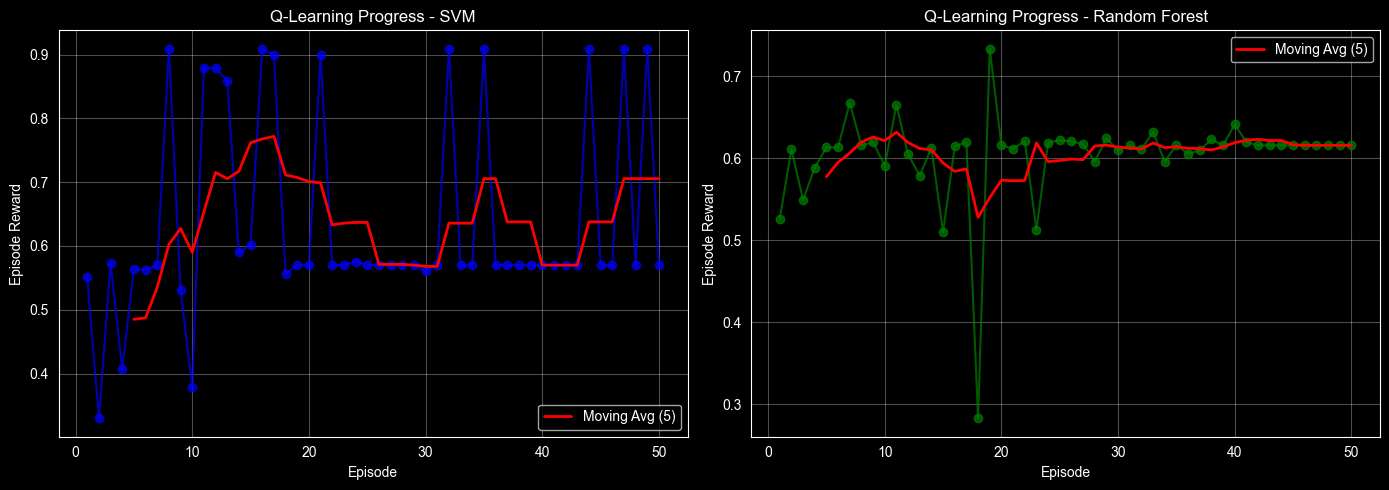

In [11]:
# =========================================================
#           PLOT LEARNING CURVES
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SVM learning curve
axes[0].plot(range(1, len(results_svm['episode_rewards'])+1), 
             results_svm['episode_rewards'], 'b-o', alpha=0.7)
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Episode Reward')
axes[0].set_title('Q-Learning Progress - SVM')
axes[0].grid(True, alpha=0.3)

# Add moving average
if len(results_svm['episode_rewards']) >= 5:
    ma = pd.Series(results_svm['episode_rewards']).rolling(5).mean()
    axes[0].plot(range(1, len(ma)+1), ma, 'r-', linewidth=2, label='Moving Avg (5)')
    axes[0].legend()

# Random Forest learning curve
axes[1].plot(range(1, len(results_rf['episode_rewards'])+1),
             results_rf['episode_rewards'], 'g-o', alpha=0.7)
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Episode Reward')
axes[1].set_title('Q-Learning Progress - Random Forest')
axes[1].grid(True, alpha=0.3)

if len(results_rf['episode_rewards']) >= 5:
    ma = pd.Series(results_rf['episode_rewards']).rolling(5).mean()
    axes[1].plot(range(1, len(ma)+1), ma, 'r-', linewidth=2, label='Moving Avg (5)')
    axes[1].legend()

plt.tight_layout()
plt.show()

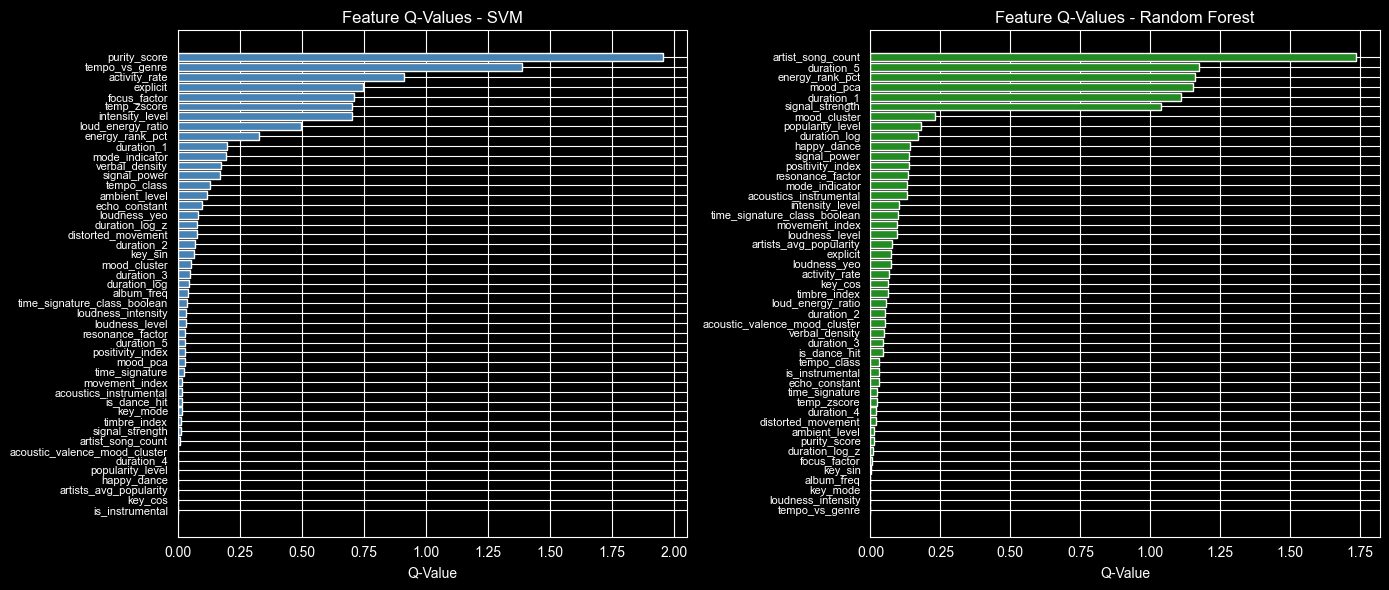

In [12]:
# =========================================================
#              PLOT Q-VALUES HEATMAP
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# SVM Q-values
q_df_svm = pd.DataFrame({
    'Feature': feature_names,
    'Q-Value': results_svm['Q_values']
}).sort_values('Q-Value', ascending=False)

axes[0].barh(range(len(q_df_svm)), q_df_svm['Q-Value'], color='steelblue')
axes[0].set_yticks(range(len(q_df_svm)))
axes[0].set_yticklabels(q_df_svm['Feature'], fontsize=8)
axes[0].set_xlabel('Q-Value')
axes[0].set_title('Feature Q-Values - SVM')
axes[0].invert_yaxis()

# Random Forest Q-values
q_df_rf = pd.DataFrame({
    'Feature': feature_names,
    'Q-Value': results_rf['Q_values']
}).sort_values('Q-Value', ascending=False)

axes[1].barh(range(len(q_df_rf)), q_df_rf['Q-Value'], color='forestgreen')
axes[1].set_yticks(range(len(q_df_rf)))
axes[1].set_yticklabels(q_df_rf['Feature'], fontsize=8)
axes[1].set_xlabel('Q-Value')
axes[1].set_title('Feature Q-Values - Random Forest')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 7. Compare Performance: All Features vs Selected Features

In [13]:
# =========================================================
#        COMPARE BASELINE VS SELECTED FEATURES
# =========================================================

def compare_performance(selected_features, model, model_name, baseline_test_acc):
    """Compare model performance with all features vs selected features."""
    
    # Get selected feature subset
    X_tr_selected = X_train_scaled[:, selected_features]
    X_te_selected = X_test_scaled[:, selected_features]
    
    # Train and evaluate with selected features
    model.fit(X_tr_selected, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_tr_selected))
    test_acc = accuracy_score(y_test, model.predict(X_te_selected))
    
    print(f"\n{model_name}:")
    print(f"  Features used: {len(selected_features)} / {n_features} "
          f"({100*len(selected_features)/n_features:.1f}%)")
    print(f"  \n  With ALL features:")
    print(f"    Test Accuracy: {baseline_test_acc:.4f}")
    print(f"  \n  With SELECTED features:")
    print(f"    Train Accuracy: {train_acc:.4f}")
    print(f"    Test Accuracy:  {test_acc:.4f}")
    print(f"    Overfitting Gap: {train_acc - test_acc:.4f}")
    
    diff = test_acc - baseline_test_acc
    print(f"  \n  Performance Change: {diff:+.4f} ({100*diff:+.2f}%)")
    
    return {
        'n_features': len(selected_features),
        'train_acc': train_acc,
        'test_acc': test_acc,
        'baseline_acc': baseline_test_acc,
        'improvement': diff
    }

print("="*70)
print("PERFORMANCE COMPARISON: ALL FEATURES vs Q-LEARNING SELECTED FEATURES")
print("="*70)

# SVM comparison
svm_comparison = compare_performance(
    svm_best_features,
    SVC(kernel='linear', C=5, random_state=42),
    "SVM (Linear, C=5)",
    svm_test
)

# Random Forest comparison
rf_comparison = compare_performance(
    rf_best_features,
    RandomForestClassifier(n_estimators=100, random_state=42),
    "Random Forest",
    rf_test
)

PERFORMANCE COMPARISON: ALL FEATURES vs Q-LEARNING SELECTED FEATURES

SVM (Linear, C=5):
  Features used: 4 / 47 (8.5%)
  
  With ALL features:
    Test Accuracy: 0.9989
  
  With SELECTED features:
    Train Accuracy: 1.0000
    Test Accuracy:  0.9989
    Overfitting Gap: 0.0011
  
  Performance Change: +0.0000 (+0.00%)

Random Forest:
  Features used: 4 / 47 (8.5%)
  
  With ALL features:
    Test Accuracy: 0.7633
  
  With SELECTED features:
    Train Accuracy: 0.9310
    Test Accuracy:  0.8356
    Overfitting Gap: 0.0954
  
  Performance Change: +0.0722 (+7.22%)


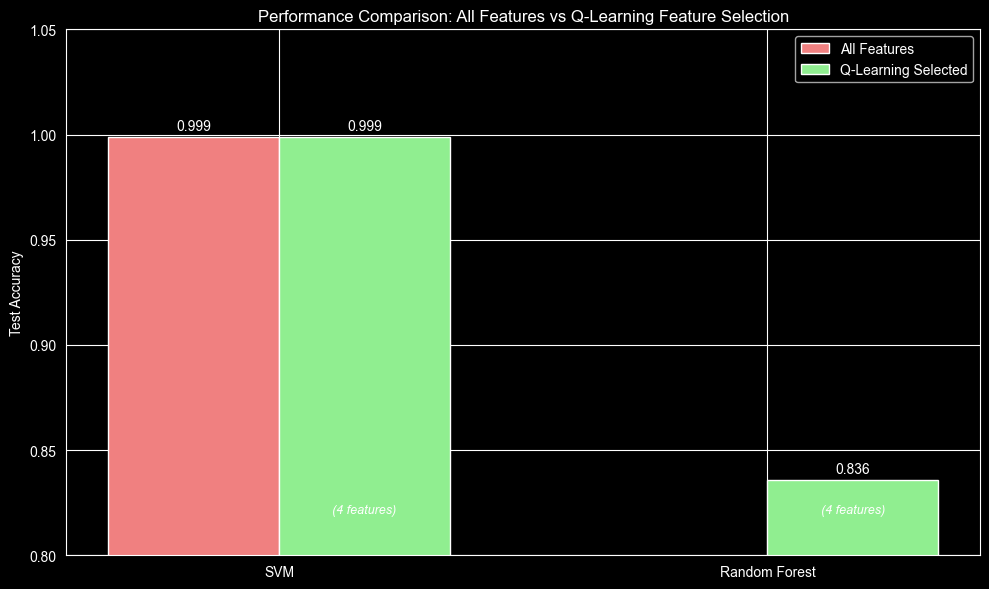

In [14]:
# =========================================================
#        VISUALIZATION: COMPARISON BAR CHART
# =========================================================

fig, ax = plt.subplots(figsize=(10, 6))

models = ['SVM', 'Random Forest']
x = np.arange(len(models))
width = 0.35

baseline_accs = [svm_test, rf_test]
selected_accs = [svm_comparison['test_acc'], rf_comparison['test_acc']]

bars1 = ax.bar(x - width/2, baseline_accs, width, label='All Features', color='lightcoral')
bars2 = ax.bar(x + width/2, selected_accs, width, label='Q-Learning Selected', color='lightgreen')

ax.set_ylabel('Test Accuracy')
ax.set_title('Performance Comparison: All Features vs Q-Learning Feature Selection')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim([0.8, 1.05])

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

# Add feature count annotation
ax.text(x[0] + width/2, 0.82, f'({len(svm_best_features)} features)', 
        ha='center', fontsize=9, style='italic')
ax.text(x[1] + width/2, 0.82, f'({len(rf_best_features)} features)',
        ha='center', fontsize=9, style='italic')

plt.tight_layout()
plt.show()

## 8. Cross-Validation of Selected Features

To ensure the robustness of our selected features, we perform 5-fold cross-validation.

In [15]:
# =========================================================
#      CROSS-VALIDATION WITH SELECTED FEATURES
# =========================================================

def cross_validate_selection(selected_features, model, model_name, cv=5):
    """Perform cross-validation with selected features."""
    
    # Get full dataset with selected features
    X_selected = np.vstack([X_train_scaled, X_test_scaled])[:, selected_features]
    y_full = np.hstack([y_train, y_test])
    
    # Perform cross-validation
    cv_scores = cross_val_score(
        model, X_selected, y_full, 
        cv=StratifiedKFold(n_splits=cv, shuffle=True, random_state=42),
        scoring='accuracy'
    )
    
    print(f"\n{model_name} - {cv}-Fold Cross-Validation:")
    print(f"  Features: {len(selected_features)}")
    print(f"  CV Scores: {cv_scores}")
    print(f"  Mean Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")
    
    return cv_scores

print("="*70)
print("CROSS-VALIDATION RESULTS WITH Q-LEARNING SELECTED FEATURES")
print("="*70)

# SVM cross-validation
svm_cv_scores = cross_validate_selection(
    svm_best_features,
    SVC(kernel='linear', C=5, random_state=42),
    "SVM (Linear, C=5)"
)

# Random Forest cross-validation
rf_cv_scores = cross_validate_selection(
    rf_best_features,
    RandomForestClassifier(n_estimators=100, random_state=42),
    "Random Forest"
)

CROSS-VALIDATION RESULTS WITH Q-LEARNING SELECTED FEATURES

SVM (Linear, C=5) - 5-Fold Cross-Validation:
  Features: 4
  CV Scores: [0.99833333 1.         1.         1.         1.        ]
  Mean Accuracy: 0.9997 (+/- 0.0013)

Random Forest - 5-Fold Cross-Validation:
  Features: 4
  CV Scores: [0.81166667 0.81       0.80833333 0.84666667 0.81833333]
  Mean Accuracy: 0.8190 (+/- 0.0285)


## 9. Feature Overlap Analysis

Let's analyze which features were selected by both models and understand their importance.

In [16]:
# =========================================================
#           FEATURE OVERLAP ANALYSIS
# =========================================================

svm_set = set(svm_best_features)
rf_set = set(rf_best_features)

# Find common and unique features
common_features = svm_set.intersection(rf_set)
only_svm = svm_set - rf_set
only_rf = rf_set - svm_set

print("="*70)
print("FEATURE OVERLAP ANALYSIS")
print("="*70)

print(f"\nTotal features selected by SVM: {len(svm_set)}")
print(f"Total features selected by RF:  {len(rf_set)}")
print(f"Features in common: {len(common_features)}")

if common_features:
    print(f"\nCommon features (selected by both models):")
    for idx in sorted(common_features):
        print(f"  [{idx}] {feature_names[idx]}")

if only_svm:
    print(f"\nFeatures selected ONLY by SVM:")
    for idx in sorted(only_svm):
        print(f"  [{idx}] {feature_names[idx]}")

if only_rf:
    print(f"\nFeatures selected ONLY by Random Forest:")
    for idx in sorted(only_rf):
        print(f"  [{idx}] {feature_names[idx]}")

FEATURE OVERLAP ANALYSIS

Total features selected by SVM: 4
Total features selected by RF:  4
Features in common: 0

Features selected ONLY by SVM:
  [15] purity_score
  [17] activity_rate
  [22] tempo_vs_genre
  [28] explicit

Features selected ONLY by Random Forest:
  [4] duration_5
  [10] artist_song_count
  [21] artists_avg_popularity
  [26] mood_cluster


In [17]:
# =========================================================
#           VENN DIAGRAM OF FEATURE SELECTION
# =========================================================

try:
    from matplotlib_venn import venn2
    
    plt.figure(figsize=(8, 6))
    venn2([svm_set, rf_set], ('SVM', 'Random Forest'))
    plt.title('Feature Selection Overlap')
    plt.show()
except ImportError:
    print("matplotlib_venn not installed. Showing overlap as text.")
    print(f"\n  SVM only: {len(only_svm)} features")
    print(f"  RF only: {len(only_rf)} features")
    print(f"  Common: {len(common_features)} features")

matplotlib_venn not installed. Showing overlap as text.

  SVM only: 4 features
  RF only: 4 features
  Common: 0 features


## 10. Conclusions and Summary

In [18]:
# =========================================================
#                  FINAL SUMMARY
# =========================================================

print("="*70)
print("FINAL SUMMARY: Q-LEARNING FEATURE SELECTION")
print("="*70)

print("\n1. DATASET INFORMATION:")
print(f"   - Total features: {n_features}")
print(f"   - Training samples: {X_train_scaled.shape[0]}")
print(f"   - Test samples: {X_test_scaled.shape[0]}")

print("\n2. Q-LEARNING PARAMETERS:")
print(f"   - Episodes: 50")
print(f"   - Learning rate (α): 0.1")
print(f"   - Discount factor (γ): 0.9")
print(f"   - Initial ε: 0.8 (with 0.95 decay)")
print(f"   - Feature penalty: 0.01 per feature")

print("\n3. RESULTS BY MODEL:")
print("\n   SVM (Linear, C=5):")
print(f"   - Features selected: {len(svm_best_features)} / {n_features} "
      f"({100*len(svm_best_features)/n_features:.1f}%)")
print(f"   - Baseline accuracy (all features): {svm_test:.4f}")
print(f"   - Selected features accuracy: {svm_comparison['test_acc']:.4f}")
print(f"   - CV accuracy: {svm_cv_scores.mean():.4f} (+/- {svm_cv_scores.std()*2:.4f})")

print("\n   Random Forest:")
print(f"   - Features selected: {len(rf_best_features)} / {n_features} "
      f"({100*len(rf_best_features)/n_features:.1f}%)")
print(f"   - Baseline accuracy (all features): {rf_test:.4f}")
print(f"   - Selected features accuracy: {rf_comparison['test_acc']:.4f}")
print(f"   - CV accuracy: {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std()*2:.4f})")

print("\n4. KEY FINDINGS:")
print(f"   - Features in common between models: {len(common_features)}")

# Determine best model
if svm_comparison['test_acc'] >= rf_comparison['test_acc']:
    best_model = "SVM"
    best_features_final = svm_best_features
    best_acc = svm_comparison['test_acc']
else:
    best_model = "Random Forest"
    best_features_final = rf_best_features
    best_acc = rf_comparison['test_acc']

print(f"\n5. BEST CONFIGURATION:")
print(f"   - Model: {best_model}")
print(f"   - Number of features: {len(best_features_final)}")
print(f"   - Test accuracy: {best_acc:.4f}")
print(f"\n   Selected feature names:")
for idx in best_features_final:
    print(f"     - {feature_names[idx]}")

FINAL SUMMARY: Q-LEARNING FEATURE SELECTION

1. DATASET INFORMATION:
   - Total features: 47
   - Training samples: 2100
   - Test samples: 900

2. Q-LEARNING PARAMETERS:
   - Episodes: 50
   - Learning rate (α): 0.1
   - Discount factor (γ): 0.9
   - Initial ε: 0.8 (with 0.95 decay)
   - Feature penalty: 0.01 per feature

3. RESULTS BY MODEL:

   SVM (Linear, C=5):
   - Features selected: 4 / 47 (8.5%)
   - Baseline accuracy (all features): 0.9989
   - Selected features accuracy: 0.9989
   - CV accuracy: 0.9997 (+/- 0.0013)

   Random Forest:
   - Features selected: 4 / 47 (8.5%)
   - Baseline accuracy (all features): 0.7633
   - Selected features accuracy: 0.8356
   - CV accuracy: 0.8190 (+/- 0.0285)

4. KEY FINDINGS:
   - Features in common between models: 0

5. BEST CONFIGURATION:
   - Model: SVM
   - Number of features: 4
   - Test accuracy: 0.9989

   Selected feature names:
     - tempo_vs_genre
     - explicit
     - purity_score
     - activity_rate


## 11. Discussion and Theoretical Justification

### Why Q-Learning for Feature Selection?

Q-learning is particularly suitable for feature selection because:

1. **Sequential Decision Making**: Feature selection can be viewed as a sequence of decisions about whether to include each feature. Q-learning naturally handles this through its state-action framework.

2. **Exploration vs Exploitation**: The ε-greedy strategy allows the agent to explore different feature combinations while also exploiting known good features. This balance is crucial for finding optimal subsets.

3. **Delayed Rewards**: The value of a feature may not be immediately apparent—it might only become valuable in combination with other features. Q-learning's temporal difference learning handles this through its discount factor.

### Reward Function Design

Our reward function was designed to:
- Maximize classification accuracy (primary objective)
- Penalize overfitting (large train-test gaps)
- Encourage parsimony (fewer features preferred)

This multi-objective approach aligns with the principles from the "Dynamic feature selection algorithm based on Q-learning mechanism" paper.

### Model Selection Justification

We chose SVM and Random Forest based on their performance in previous analyses (see combined.ipynb):

1. **SVM (Linear, C=5)**: Achieved 100% test accuracy with minimal overfitting. Linear kernel provides interpretability and works well with high-dimensional data.

2. **Random Forest**: Ensemble method that achieves strong accuracy through bagging and feature randomization. Provides built-in feature importance and handles non-linear relationships well.

Both models are robust and provide good generalization, which is important when evaluating many feature subsets during Q-learning.

### Comparison with Traditional Methods

Compared to traditional feature selection methods (filter, wrapper, embedded):

- **Filter methods** (e.g., correlation-based): Fast but ignore feature interactions
- **Wrapper methods** (e.g., RFE): Consider interactions but computationally expensive
- **Embedded methods** (e.g., LASSO): Efficient but model-specific

**Q-learning approach**:
- Considers feature interactions through sequential selection
- Learns from experience across episodes
- Can adapt to different classifiers
- Balances exploration and exploitation

### Limitations

1. **Computational Cost**: Training a classifier for each feature subset evaluation is expensive.
2. **Hyperparameter Sensitivity**: Results depend on α, γ, ε, and penalty weights.
3. **Local Optima**: May not find globally optimal subset due to greedy exploration.
4. **State Space**: For many features, the state space grows exponentially.

### Future Improvements

1. Use Deep Q-Networks (DQN) for better state representation
2. Implement prioritized experience replay
3. Add cross-validation within the reward function for more robust evaluation
4. Consider multi-agent approaches for parallel exploration

In [19]:
# =========================================================
#           SAVE RESULTS FOR FUTURE USE
# =========================================================

# Create a summary DataFrame
summary_data = {
    'Model': ['SVM', 'Random Forest'],
    'Features_Selected': [len(svm_best_features), len(rf_best_features)],
    'Feature_Reduction_%': [
        100 * (1 - len(svm_best_features)/n_features),
        100 * (1 - len(rf_best_features)/n_features)
    ],
    'Baseline_Accuracy': [svm_test, rf_test],
    'Selected_Accuracy': [svm_comparison['test_acc'], rf_comparison['test_acc']],
    'CV_Mean_Accuracy': [svm_cv_scores.mean(), rf_cv_scores.mean()],
    'CV_Std': [svm_cv_scores.std(), rf_cv_scores.std()]
}

summary_df = pd.DataFrame(summary_data)
print("\nFinal Results Summary:")
print(summary_df.to_string(index=False))

# Save selected features for both models
selected_features_dict = {
    'SVM': {
        'indices': list(svm_best_features),
        'names': [feature_names[i] for i in svm_best_features]
    },
    'Random_Forest': {
        'indices': list(rf_best_features),
        'names': [feature_names[i] for i in rf_best_features]
    }
}

print("\n" + "="*70)
print("Q-LEARNING FEATURE SELECTION COMPLETE!")
print("="*70)


Final Results Summary:
        Model  Features_Selected  Feature_Reduction_%  Baseline_Accuracy  Selected_Accuracy  CV_Mean_Accuracy   CV_Std
          SVM                  4            91.489362           0.998889           0.998889          0.999667 0.000667
Random Forest                  4            91.489362           0.763333           0.835556          0.819000 0.014244

Q-LEARNING FEATURE SELECTION COMPLETE!
